# Summarize Calibration Targets

We use this scirpt to summarize mode choice calibration targets.  Underlying our analysis is a simple mode choice model where the user chooses between ride-hailing, transit and walk.  Our model applies specifically within the City of Chicago, excluding airports.  Therefore, we start by summarizing the number of trips on each mode within our target area.  Note that for ride-hailing, we have two possible data sources: the household travel survey and the Chicago TNP data.  The TNP data are an enumeration, so we prefer those over the HH survey, which is a smaller sample.  


In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.reset_option('display.float_format')

import matplotlib.pyplot as plt
import numpy as np

from statsmodels.stats.weightstats import DescrStatsW

from codebook import Codebook
cb = Codebook()

In [2]:
## start with just the survey data
trip_linked = pd.read_csv('data/trip_linked_2024.csv',
    dtype={'o_tract_2020': 'Int64', 'd_tract_2020': 'Int64'})
trip_linked

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60057,24601170,2460117004,4,246011700401,1,2460117000102,29,2025-06-04,18,20,0.0,2025-06-04,18,30,0.0,2230,1.385661,10,10.0,0,0,0,17197880318,17197880317,1,0,1,1,0,0,0,0,0,0,51,9,102,8,4,2,0,0,2460117004010202,2,8,1,3,308.896900,24601170040102,2
60058,24601170,2460117004,4,246011700401,1,2460117000103,30,2025-06-04,18,40,0.0,2025-06-04,18,45,0.0,381,0.236743,5,30.0,0,0,0,17197880317,17197880317,1,0,1,1,0,0,0,0,0,0,102,8,99,10,4,3,0,0,2460117004010203,3,8,1,3,308.896900,24601170040102,2
60059,24601170,2460117004,4,246011700401,1,2460117000104,31,2025-06-04,19,15,0.0,2025-06-04,19,40,0.0,23964,14.890576,25,NaN,0,0,0,17197880317,17093890703,1,0,1,1,0,0,0,0,0,0,99,10,1,1,4,4,0,1,2460117004010204,4,8,0,3,308.896900,24601170040102,2
60060,24601172,2460117201,1,246011720101,1,-1,NaN,2025-06-04,8,0,0.0,2025-06-04,8,1,0.0,18884,11.734003,1,39.0,1,0,0,17097864511,17031803300,1,0,0,0,0,0,0,0,0,0,1,1,10,2,2,1,1,0,2460117201010101,1,10,1,1,1494.058248,24601172010101,1


First we want to understand what the data represent and which weights to use.  Start by looking through cmap_hts_dataset_guide.html, particularly the section on weights.  

After reviewing the documenation, it -appears- that the trips are expanded to represent typical weekday (Tue-Thu) conditions.  We want to use the linked trips, and will use the linked trip weights.  


To help make these more readable, in a way analogous to what is shown for R in the documentation, I created a phython helper class.  This usage is as follows: 

``` python 
from codebook import Codebook
cb = Codebook()

# R: factor(transit_freq, levels=..., labels=...)
person["transit_freq_f"] = cb.as_categorical(person["transit_freq"], "person", "transit_freq")

# Lighter: just swap codes for labels
person["transit_freq_label"] = cb.decode(person["transit_freq"], "person", "transit_freq")

# Lookup a variable's description / data type / skip logic
cb.describe("person", "transit_freq")

# Browse everything documented for a table
cb.variables_in("person")
```

In [3]:
# Let's look at an example summarizing the frequency of trip modes

trip_linked['linked_trip_mode_labeled'] = cb.decode(trip_linked['linked_trip_mode'], 'trip_linked', 'linked_trip_mode')

pd.DataFrame({
    'count':    trip_linked['linked_trip_mode_labeled'].value_counts(),
    'weighted': trip_linked.groupby('linked_trip_mode_labeled')['linked_trip_weight'].sum(),
}).sort_index().round()


,count,weighted
linked_trip_mode_labeled,,
Bike,1235,359491.0
Drive to bus,51,55563.0
Drive to rail,267,321613.0
HOV (2 people),11973,6838662.0
HOV (3+ people),9841,5282716.0
Long distance mode,43,22065.0
Micromobility,51,13375.0
Not imputable,1113,111951.0
Other,311,201671.0


In [4]:
# now let's recode these into a shorter set of modes:

mode_recode = {
	-1 : 'not_imputable',  # Not imputable
	1  : 'school_bus',     # School bus
	2  : 'transit',        # Drive to ferry
	3  : 'transit',        # Drive to rail
	4  : 'transit',        # Drive to bus
	5  : 'transit',        # Walk to ferry
	6  : 'transit',        # Walk to rail
	7  : 'transit',        # Walk to bus
	8  : 'car',            # HOV (3+ people)
	9  : 'car',            # HOV (2 people)
	10 : 'car',            # SOV
	11 : 'bike',           # Bike
	12 : 'bike',           # Micromobility
	13 : 'tnc',            # Taxi
	14 : 'tnc',            # TNC
	15 : 'walk',           # Walk
	16 : 'other',          # Long distance mode
	17 : 'other',          # Other
	18 : 'transit'         # Transit
}

trip_linked['mode'] = trip_linked['linked_trip_mode'].map(mode_recode)

In [5]:
# now check that it makes sense
pd.DataFrame({
    'count':    trip_linked['mode'].value_counts(),
    'weighted': trip_linked.groupby('mode')['linked_trip_weight'].sum(),
}).sort_index().round()

,count,weighted
mode,,
bike,1286,372867.0
car,42958,24928666.0
not_imputable,1113,111951.0
other,354,223736.0
school_bus,881,671795.0
tnc,853,393457.0
transit,2836,2123921.0
walk,9781,3898687.0


In [6]:
# Now let's join in the place names so we can identify which trips start and end in Chicago, and summarize by districts. 

# load the lookup
df_tract_district = pd.read_csv('data/tract_2020_district.csv')   
tract_to_district = dict(zip(df_tract_district['GEOID'], df_tract_district['RH_Zone']))

trip_linked['o_district'] = trip_linked['o_tract_2020'].map(tract_to_district)
trip_linked['d_district'] = trip_linked['d_tract_2020'].map(tract_to_district)

trip_linked

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,o_district,d_district
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60057,24601170,2460117004,4,246011700401,1,2460117000102,29,2025-06-04,18,20,0.0,2025-06-04,18,30,0.0,2230,1.385661,10,10.0,0,0,0,17197880318,17197880317,1,0,1,1,0,0,0,0,0,0,51,9,102,8,4,2,0,0,2460117004010202,2,8,1,3,308.896900,24601170040102,2,HOV (3+ people),car,External,External
60058,24601170,2460117004,4,246011700401,1,2460117000103,30,2025-06-04,18,40,0.0,2025-06-04,18,45,0.0,381,0.236743,5,30.0,0,0,0,17197880317,17197880317,1,0,1,1,0,0,0,0,0,0,102,8,99,10,4,3,0,0,2460117004010203,3,8,1,3,308.896900,24601170040102,2,HOV (3+ people),car,External,External
60059,24601170,2460117004,4,246011700401,1,2460117000104,31,2025-06-04,19,15,0.0,2025-06-04,19,40,0.0,23964,14.890576,25,NaN,0,0,0,17197880317,17093890703,1,0,1,1,0,0,0,0,0,0,99,10,1,1,4,4,0,1,2460117004010204,4,8,0,3,308.896900,24601170040102,2,HOV (3+ people),car,External,External
60060,24601172,2460117201,1,246011720101,1,-1,NaN,2025-06-04,8,0,0.0,2025-06-04,8,1,0.0,18884,11.734003,1,39.0,1,0,0,17097864511,17031803300,1,0,0,0,0,0,0,0,0,0,1,1,10,2,2,1,1,0,2460117201010101,1,10,1,1,1494.058248,24601172010101,1,SOV,car,External,External


In [7]:
# make the districts an ordered categorical for a nice display
order = ['Downtown', 'Tourist', 'Other', 'Airport', 'External']
cat = pd.CategoricalDtype(order, ordered=True)

trip_linked['o_district'] = trip_linked['o_district'].astype(cat)
trip_linked['d_district'] = trip_linked['d_district'].astype(cat)

In [8]:
# next we filter to exclude trips we don't have in our TNC data.

print("Keep only trips with origin and destination in Chicago")
trips_before = len(trip_linked)
trip_linked = trip_linked[(trip_linked['o_district'] != 'External') & (trip_linked['d_district'] != 'External') ].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Keep only trips with origin and destination in Chicago
Before: 60062 After: 22003


In [9]:
# next we filter to exclude trips we don't have in our TNC data.
# We could re-consider whether to drop the airport trips.  It's not obvious it's necessary to drop them, but there are not many here. 

print("Drop trips to/from airports")
trips_before = len(trip_linked)
trip_linked = trip_linked[(trip_linked['o_district'] != 'Airport') & (trip_linked['d_district'] != 'Airport') ].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Drop trips to/from airports
Before: 22003 After: 21824


In [10]:
# summarize the modes again
pd.DataFrame({
    'count':    trip_linked['mode'].value_counts(),
    'weighted': trip_linked.groupby('mode')['linked_trip_weight'].sum(),
}).sort_index().round()

,count,weighted
mode,,
bike,1061,266259.0
car,9570,4655304.0
not_imputable,635,49537.0
other,156,82028.0
school_bus,487,140768.0
tnc,604,236648.0
transit,2160,1201987.0
walk,7151,2352940.0


In [11]:
# Look at just tnc, transit and walk by district
tnc = trip_linked[trip_linked['mode']=='tnc']

print('TNC Trips - Observations')
display(pd.crosstab(tnc['o_district'], tnc['d_district'], margins=True).style.format('{:,.0f}'))

print('TNC Trips - Weighted & Expanded')
tnc_crosstab = pd.crosstab(tnc['o_district'], tnc['d_district'], values=tnc['linked_trip_weight'], aggfunc='sum', margins=True)
display(tnc_crosstab.style.format('{:,.0f}'))

TNC Trips - Observations


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,86,4,81,171
Tourist,1,0,4,5
Other,80,1,243,324
All,167,5,328,500


TNC Trips - Weighted & Expanded


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,"17,455",283,"36,309",0,0,"54,047"
Tourist,0,0,"1,025",0,0,"1,025"
Other,"20,261","9,497","110,434",0,0,"140,193"
Airport,0,0,0,0,0,nan
External,0,0,0,0,0,nan
All,"37,716","9,781","147,769",nan,nan,"195,265"


In [12]:
# Look at just tnc, transit and walk by district
transit = trip_linked[trip_linked['mode']=='transit']

print('Transit Trips - Observations')
display(pd.crosstab(transit['o_district'], transit['d_district'], margins=True).style.format('{:,.0f}'))

print('Transit Trips - Weighted & Expanded')
transit_crosstab = pd.crosstab(transit['o_district'], transit['d_district'], values=transit['linked_trip_weight'], aggfunc='sum', margins=True)
display(transit_crosstab.style.format('{:,.0f}'))

Transit Trips - Observations


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,160,4,459,623
Tourist,3,0,7,10
Other,501,9,890,"1,400"
All,664,13,"1,356","2,033"


Transit Trips - Weighted & Expanded


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,"116,531","1,257","203,717",0,0,"321,505"
Tourist,"1,183",0,"9,656",0,0,"10,839"
Other,"274,745","2,058","540,460",0,0,"817,263"
Airport,0,0,0,0,0,nan
External,0,0,0,0,0,nan
All,"392,459","3,315","753,833",nan,nan,"1,149,608"


In [13]:
# Look at just tnc, transit and walk by district
walk = trip_linked[trip_linked['mode']=='walk']

print('Walk Trips - Observations')
display(pd.crosstab(walk['o_district'], walk['d_district'], margins=True).style.format('{:,.0f}'))

print('Walk Trips - Weighted & Expanded')
walk_crosstab = pd.crosstab(walk['o_district'], walk['d_district'], values=walk['linked_trip_weight'], aggfunc='sum', margins=True)
display(walk_crosstab.style.format('{:,.0f}'))

Walk Trips - Observations


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,"1,444",26,108,"1,578"
Tourist,30,23,4,57
Other,85,5,"4,692","4,782"
All,"1,559",54,"4,804","6,417"


Walk Trips - Weighted & Expanded


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,"432,726","3,964","77,896",0,0,"514,587"
Tourist,"4,260","6,075","2,622",0,0,"12,957"
Other,"48,534","4,919","1,499,889",0,0,"1,553,343"
Airport,0,0,0,0,0,nan
External,0,0,0,0,0,nan
All,"485,521","14,959","1,580,408",nan,nan,"2,080,887"


In [14]:
# now print the mode shares
total_crosstab = tnc_crosstab + transit_crosstab + walk_crosstab
tnc_share = tnc_crosstab / total_crosstab
transit_share = transit_crosstab / total_crosstab
walk_share = walk_crosstab / total_crosstab

print('TNC Mode Share')
display(tnc_share.style.format('{:.1%}'))

print('Transit Mode Share')
display(transit_share.style.format('{:.1%}'))

print('Walk Mode Share')
display(walk_share.style.format('{:.1%}'))

TNC Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,3.1%,5.1%,11.4%,nan%,nan%,6.1%
Tourist,0.0%,0.0%,7.7%,nan%,nan%,4.1%
Other,5.9%,57.6%,5.1%,nan%,nan%,5.6%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,4.1%,34.9%,6.0%,nan%,nan%,5.7%


Transit Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,20.6%,22.8%,64.1%,nan%,nan%,36.1%
Tourist,21.7%,0.0%,72.6%,nan%,nan%,43.7%
Other,80.0%,12.5%,25.1%,nan%,nan%,32.5%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,42.9%,11.8%,30.4%,nan%,nan%,33.6%


Walk Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,76.4%,72.0%,24.5%,nan%,nan%,57.8%
Tourist,78.3%,100.0%,19.7%,nan%,nan%,52.2%
Other,14.1%,29.9%,69.7%,nan%,nan%,61.9%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,53.0%,53.3%,63.7%,nan%,nan%,60.7%


Walk seems to be too big of a share here.  I suspect there are many where walk does not really compete with ride-hailing and transit.  Let's think about what can or should be excluded. 

In [15]:
walk

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,o_district,d_district
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59996,24601150,2460115006,6,246011500601,1,-1,27,2025-06-05,15,10,0.0,2025-06-05,15,25,0.0,1162,0.722035,15,145.0,0,0,0,17031050500,17031050200,0,0,0,0,1,1,0,0,0,0,21,4,1,1,3,3,0,1,2460115006010103,3,15,0,3,1371.070300,24601150060101,1,Walk,walk,Other,Other
60013,24601161,2460116101,1,246011610101,1,2460116100102,10,2025-06-10,10,45,0.0,2025-06-10,10,50,0.0,753,0.467894,5,140.0,0,0,0,17031320102,17031320102,1,1,0,0,0,0,0,0,0,0,51,9,51,9,4,2,0,0,2460116101010102,2,15,1,3,687.418904,24601161010101,1,Walk,walk,Downtown,Downtown
60014,24601161,2460116101,1,246011610101,1,2460116100103,11,2025-06-10,13,10,0.0,2025-06-10,13,15,0.0,753,0.467894,5,15.0,0,0,0,17031320102,17031320102,1,1,0,0,0,0,0,0,0,0,51,9,51,9,4,3,0,0,2460116101010103,3,15,0,3,687.418904,24601161010101,1,Walk,walk,Downtown,Downtown
60017,24601161,2460116102,2,246011610201,1,2460116100102,10,2025-06-10,10,45,0.0,2025-06-10,10,50,0.0,753,0.467894,5,140.0,0,0,0,17031320102,17031320102,1,1,0,0,0,0,0,0,0,0,51,9,51,9,4,2,0,0,2460116102010102,2,15,1,3,687.418904,24601161020101,1,Walk,walk,Downtown,Downtown


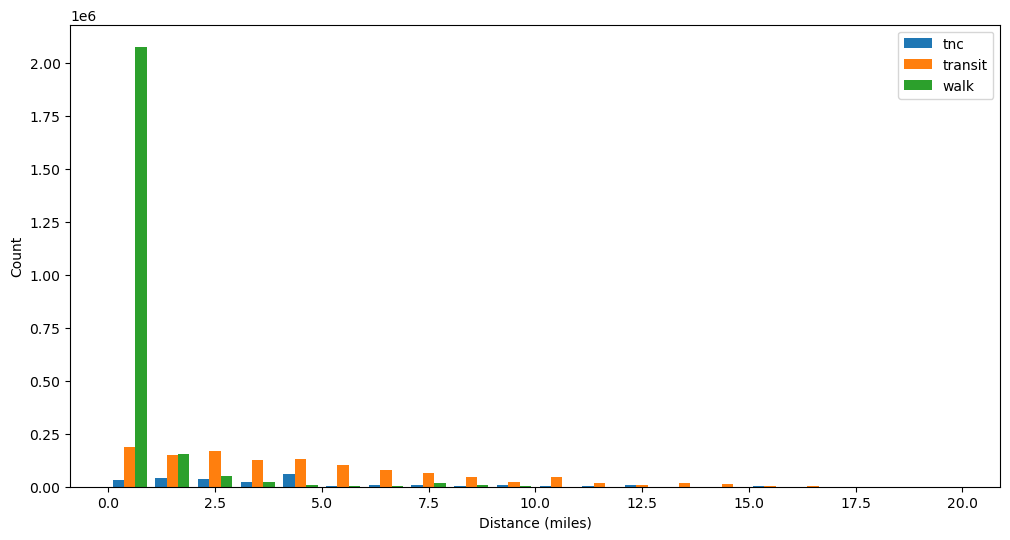

In [16]:
# plot histograms by mode
bins = np.arange(0, 21, 1)
modes = ['tnc', 'transit', 'walk']

data, weights = [], []
for m in modes:
    sub = trip_linked[(trip_linked['mode'] == m) & trip_linked['distance_miles'].notna()]
    data.append(sub['distance_miles'])
    weights.append(sub['linked_trip_weight'])

plt.figure(figsize=(12, 6))   # width, height in inches
plt.hist(data, bins=bins, weights=weights, label=modes)
plt.xlabel('Distance (miles)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [17]:
# most walk trips are short.  Let's look at the percentile distributions of length by mode
probs = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

print('tnc trip length percentiles')
print(DescrStatsW(tnc['distance_miles'], weights=tnc['linked_trip_weight']).quantile(probs))

print('transit trip length percentiles')
print(DescrStatsW(transit['distance_miles'], weights=transit['linked_trip_weight']).quantile(probs))

print('walk trip length percentiles')
print(DescrStatsW(walk['distance_miles'], weights=walk['linked_trip_weight']).quantile(probs))



tnc trip length percentiles
p
0.01     0.273404
0.05     0.460437
0.25     1.806952
0.50     3.599612
0.75     4.782706
0.95    11.056085
0.99    13.836728
dtype: float64
transit trip length percentiles
p
0.01     0.000000
0.05     0.192004
0.25     1.865361
0.50     3.684740
0.75     6.496452
0.95    12.416891
0.99    20.785539
dtype: float64
walk trip length percentiles
p
0.01    0.000000
0.05    0.000000
0.25    0.204432
0.50    0.382144
0.75    0.590925
0.95    2.088434
0.99    7.229672
dtype: float64


Only 5% of TNC trips are less than 0.5 miles, but more like 2/3 of walk trips.  It's not clear that those realistically compete, so remove those from the calibration targets. 

In [18]:
# Look at just tnc, transit and walk by district
walk = trip_linked[(trip_linked['mode']=='walk') & (trip_linked['distance_miles']>=0.5)]

print('Walk Trips - Observations')
display(pd.crosstab(walk['o_district'], walk['d_district'], margins=True).style.format('{:,.0f}'))

print('Walk Trips - Weighted & Expanded')
walk_crosstab = pd.crosstab(walk['o_district'], walk['d_district'], values=walk['linked_trip_weight'], aggfunc='sum', margins=True)
display(walk_crosstab.style.format('{:,.0f}'))


Walk Trips - Observations


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,602,17,82,701
Tourist,17,5,3,25
Other,64,2,"1,750","1,816"
All,683,24,"1,835","2,542"


Walk Trips - Weighted & Expanded


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,"130,426","2,129","66,609",0,0,"199,165"
Tourist,946,0,"1,133",0,0,"2,079"
Other,"39,442",0,"496,481",0,0,"535,924"
Airport,0,0,0,0,0,nan
External,0,0,0,0,0,nan
All,"170,815","2,129","564,223",nan,nan,"737,167"


In [19]:
# now print the mode shares with the updated walk 
total_crosstab = tnc_crosstab + transit_crosstab + walk_crosstab
tnc_share = tnc_crosstab / total_crosstab
transit_share = transit_crosstab / total_crosstab
walk_share = walk_crosstab / total_crosstab

print('TNC Mode Share')
display(tnc_share.style.format('{:.1%}'))

print('Transit Mode Share')
display(transit_share.style.format('{:.1%}'))

print('Walk Mode Share')
display(walk_share.style.format('{:.1%}'))

TNC Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,6.6%,7.7%,11.8%,nan%,nan%,9.4%
Tourist,0.0%,nan%,8.7%,nan%,nan%,7.4%
Other,6.1%,82.2%,9.6%,nan%,nan%,9.4%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,6.3%,64.2%,10.1%,nan%,nan%,9.4%


Transit Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,44.1%,34.3%,66.4%,nan%,nan%,55.9%
Tourist,55.6%,nan%,81.7%,nan%,nan%,77.7%
Other,82.1%,17.8%,47.1%,nan%,nan%,54.7%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,65.3%,21.8%,51.4%,nan%,nan%,55.2%


Walk Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,49.3%,58.0%,21.7%,nan%,nan%,34.7%
Tourist,44.4%,nan%,9.6%,nan%,nan%,14.9%
Other,11.8%,0.0%,43.3%,nan%,nan%,35.9%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,28.4%,14.0%,38.5%,nan%,nan%,35.4%


Now consider the purpose.  Are people just going going out for a stroll or a run? 

In [20]:
# Let's look at the purposes

# Note that trip_unlinked shows up only because that is the key in the documentation
trip_linked['o_purpose_category_labeled'] = cb.decode(trip_linked['o_purpose_category'], 'trip_unlinked', 'o_purpose_category')

display(pd.DataFrame({
    'count':    trip_linked['o_purpose_category_labeled'].value_counts(),
    'weighted': trip_linked.groupby('o_purpose_category_labeled')['linked_trip_weight'].sum(),
}).sort_index().style.format('{:,.0f}'))


# Note that trip_unlinked shows up only because that is the key in the documentation
trip_linked['d_purpose_category_labeled'] = cb.decode(trip_linked['d_purpose_category'], 'trip_unlinked', 'd_purpose_category')

display(pd.DataFrame({
    'count':    trip_linked['d_purpose_category_labeled'].value_counts(),
    'weighted': trip_linked.groupby('d_purpose_category_labeled')['linked_trip_weight'].sum(),
}).sort_index().style.format('{:,.0f}'))

,count,weighted
o_purpose_category_labeled,,
Change mode,33,"6,439"
Errand,"1,051","458,798"
Escort,"1,247","782,388"
Home,"7,962","3,212,538"
Meal,"1,844","461,150"
Missing Response,152,"224,887"
Not imputable,163,"13,033"
Other,293,"151,532"
Overnight,907,"220,663"


,count,weighted
d_purpose_category_labeled,,
Errand,"1,044","446,968"
Escort,"1,278","807,120"
Home,"7,995","3,297,105"
Loop,5,"6,769"
Meal,"1,895","512,571"
Missing Response,49,"45,543"
Not imputable,166,"27,334"
Other,194,"128,695"
Overnight,"1,016","324,225"


In [21]:
## look at the tour data
tour = pd.read_csv('data/tour_2024.csv')
tour

,hh_id,person_id,person_num,day_id,day_num,distance_meters,distance_miles,duration_minutes,o_tract_2020,d_tract_2020,num_travelers,num_hh_travelers,joint_status,tour_id,tour_num,joint_tour_id,tour_start_date,tour_start_hour,tour_start_minute,tour_start_second,tour_end_date,tour_end_hour,tour_end_minute,tour_end_second,tour_category,tour_mode,tour_purpose,partial_status,stops_outbound,stops_inbound,tour_weight
0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,24000124010101,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397
1,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,24000124020101,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397
2,24000124,2400012402,2,240001240201,1,5564,3.457318,165,1.703132e+10,1.703132e+10,1,1,1,24000124020102,2,NaN,2024-05-21,12,45,0.0,2024-05-21,15,30,0.0,2,15,10,0,0,0,1237.449397
3,24000140,2400014001,1,240001400101,1,2410,1.497508,19,1.703181e+10,1.703181e+10,1,1,1,24000140010101,1,NaN,2024-05-14,7,26,27.0,2024-05-14,7,45,38.0,2,15,14,1,0,0,184.687075
4,24000140,2400014001,1,240001400102,2,33817,21.012962,899,1.703181e+10,1.703181e+10,1,1,2,24000140010201,1,NaN,2024-05-15,6,27,1.0,2024-05-15,21,26,21.0,1,6,3,0,0,2,184.687075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23509,24601170,2460117002,2,246011700201,1,44331,27.546075,105,1.709389e+10,1.709389e+10,1,1,1,24601170020102,2,NaN,2025-06-04,17,15,0.0,2025-06-04,19,0,0.0,1,10,2,0,0,0,328.626172
23510,24601170,2460117003,3,246011700301,1,52667,32.725838,145,1.709389e+10,1.709389e+10,3,3,3,24601170030101,1,2.460117e+10,2025-06-04,17,15,0.0,2025-06-04,19,40,0.0,4,8,10,0,2,0,257.426400
23511,24601170,2460117004,4,246011700401,1,7993,4.966632,260,1.709389e+10,1.709389e+10,2,2,2,24601170040101,1,NaN,2025-06-04,7,50,0.0,2025-06-04,12,10,0.0,1,9,4,0,0,0,257.426400
23512,24601170,2460117004,4,246011700401,1,52667,32.725838,145,1.709389e+10,1.709389e+10,3,3,3,24601170040102,2,2.460117e+10,2025-06-04,17,15,0.0,2025-06-04,19,40,0.0,4,8,10,0,2,0,257.426400


In [22]:
# And consider the tour purpose (which are not auto-labeled)

# tour_purpose	-1	Not imputable
# tour_purpose	1	Home
# tour_purpose	2	Work
# tour_purpose	3	Work-related
# tour_purpose	4	School
# tour_purpose	5	School-related
# tour_purpose	6	Escort
# tour_purpose	7	Shop
# tour_purpose	8	Meal
# tour_purpose	9	Social or recreational
# tour_purpose	10	Errand
# tour_purpose	11	Change mode
# tour_purpose	12	Overnight
# tour_purpose	13	Other
# tour_purpose	14	Loop
# tour_purpose	995	Missing

display(pd.DataFrame({
    'count':    tour['tour_purpose'].value_counts(),
    'weighted': tour.groupby('tour_purpose')['tour_weight'].sum(),
}).sort_index().style.format('{:,.0f}'))

,count,weighted
tour_purpose,,
-1,145,"52,455"
2,"3,348","2,455,545"
3,"1,525","526,061"
4,"2,160","1,580,192"
5,120,"60,095"
6,"2,247","1,806,820"
7,"3,490","2,102,766"
8,"1,611","608,275"
9,"2,774","1,300,924"


In [23]:
# Cross-tab with the tour mode

"""
tour_mode	-1	Not imputable
tour_mode	1	School bus
tour_mode	2	Drive to ferry
tour_mode	3	Drive to rail
tour_mode	4	Drive to bus
tour_mode	5	Walk to ferry
tour_mode	6	Walk to rail
tour_mode	7	Walk to bus
tour_mode	8	HOV (3+ people)
tour_mode	9	HOV (2 people)
tour_mode	10	SOV
tour_mode	11	Bike
tour_mode	12	Micromobility
tour_mode	13	Taxi
tour_mode	14	TNC
tour_mode	15	Walk
tour_mode	16	Long distance mode
tour_mode	17	Other
tour_mode	18	Transit
"""

tour_crosstab = pd.crosstab(tour['tour_purpose'], tour['tour_mode'], values=tour['tour_weight'], aggfunc='sum', margins=True)
display(tour_crosstab.style.format('{:,.0f}'))

tour_mode,-1,1,3,4,6,7,8,9,10,11,12,13,14,15,16,17,18,All
tour_purpose,,,,,,,,,,,,,,,,,,
-1,585,"2,402",nan,nan,nan,nan,"15,183","11,222",0,0,nan,nan,nan,"23,063",nan,nan,nan,"52,455"
2,"1,009",215,"110,206","3,445","205,938","96,935","185,266","222,564","1,471,756","30,871",416,"3,662","25,907","90,772",nan,"6,583",nan,"2,455,545"
3,"4,962",651,"13,928","13,578","32,559","40,188","43,295","48,865","284,998","5,800",231,"1,997","15,455","16,937",90,"2,528",nan,"526,061"
4,884,"331,574","8,757","5,419","34,513","83,361","530,770","210,993","110,890","26,577",nan,nan,"8,504","227,949",nan,0,nan,"1,580,192"
5,0,"8,099",0,nan,"5,329","5,618","9,043","14,471","14,308",107,nan,nan,nan,"3,121",nan,nan,nan,"60,095"
6,609,"9,601","15,560",0,"39,434","16,038","776,734","685,961","108,180","11,332",nan,nan,"2,026","136,281",nan,"5,063",nan,"1,806,820"
7,"1,898",0,"4,912","8,929","61,685","107,832","347,482","564,578","855,301","9,323",0,"5,297","4,874","129,307",nan,620,727,"2,102,766"
8,191,0,"11,163",311,"14,312","15,787","134,253","148,844","204,387","2,867",44,407,722,"74,989",nan,nan,nan,"608,275"
9,64,nan,"4,746",656,"38,259","17,322","246,260","252,542","426,656","33,671",498,0,"16,211","244,021",nan,"20,017",nan,"1,300,924"


We see from the tabulation above (row 14, column 15) that over half of the walk tours are for purpose "loop".  This is someone going for a run or a stroll and the point is recreation.  We should drop these from our targets too.  

In [24]:
# join the trips to the tours
trip_linked = trip_linked.merge(tour, on='tour_id', how='left', suffixes=['', '_tour'])
trip_linked

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,o_district,d_district,o_purpose_category_labeled,d_purpose_category_labeled,hh_id_tour,person_id_tour,person_num_tour,day_id_tour,day_num_tour,distance_meters_tour,distance_miles_tour,duration_minutes_tour,o_tract_2020_tour,d_tract_2020_tour,num_travelers,num_hh_travelers,joint_status_tour,tour_num_tour,joint_tour_id,tour_start_date,tour_start_hour,tour_start_minute,tour_start_second,tour_end_date,tour_end_hour,tour_end_minute,tour_end_second,tour_category,tour_mode,tour_purpose,partial_status,stops_outbound,stops_inbound,tour_weight
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,Home,Errand,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,Errand,Overnight,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,Overnight,Errand,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,Errand,Home,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown,Home,Errand,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21819,24601164,2460116402,2,246011640201,1,-1,NaN,2025-06-05,18,0,0.0,2025-06-05,18,15,0.0,1069,0.664247,15,NaN,0,0,0,17031063303,17031070200,0,1,0,0,0,0,0,0,0,0,10,2,1,1,2,2,0,1,2460116402010102,2,10,0,1,50.936512,24601164020101,1,SOV,car,Other,Other,Work,Home,24601164,2460116402,2,2460

In [25]:
# Now look at the walk trips, excluding the loops
# Look at just tnc, transit and walk by district
walk = trip_linked[(trip_linked['mode']=='walk') & (trip_linked['distance_miles']>=0.5) & (trip_linked['tour_purpose']!=14)]

print('Walk Trips - Observations')
display(pd.crosstab(walk['o_district'], walk['d_district'], margins=True).style.format('{:,.0f}'))

print('Walk Trips - Weighted & Expanded')
walk_crosstab = pd.crosstab(walk['o_district'], walk['d_district'], values=walk['linked_trip_weight'], aggfunc='sum', margins=True)
display(walk_crosstab.style.format('{:,.0f}'))


Walk Trips - Observations


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,561,17,81,659
Tourist,17,2,3,22
Other,63,2,"1,421","1,486"
All,641,21,"1,505","2,167"


Walk Trips - Weighted & Expanded


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,"127,897","2,129","66,609",0,0,"196,636"
Tourist,946,0,"1,133",0,0,"2,079"
Other,"39,347",0,"447,795",0,0,"487,142"
Airport,0,0,0,0,0,nan
External,0,0,0,0,0,nan
All,"168,190","2,129","515,537",nan,nan,"685,856"


In [26]:
# print both the absolute totals and the mode shares

# TNC
tnc = trip_linked[trip_linked['mode']=='tnc']
print('TNC Trips - Observations')
display(pd.crosstab(tnc['o_district'], tnc['d_district'], margins=True).style.format('{:,.0f}'))

print('TNC Trips - Weighted & Expanded')
tnc_crosstab = pd.crosstab(tnc['o_district'], tnc['d_district'], values=tnc['linked_trip_weight'], aggfunc='sum', margins=True)
display(tnc_crosstab.style.format('{:,.0f}'))

# Transit
transit = trip_linked[trip_linked['mode']=='transit']
print('Transit Trips - Observations')
display(pd.crosstab(transit['o_district'], transit['d_district'], margins=True).style.format('{:,.0f}'))

print('Transit Trips - Weighted & Expanded')
transit_crosstab = pd.crosstab(transit['o_district'], transit['d_district'], values=transit['linked_trip_weight'], aggfunc='sum', margins=True)
display(transit_crosstab.style.format('{:,.0f}'))

# Walk
walk = trip_linked[(trip_linked['mode']=='walk') & (trip_linked['distance_miles']>=0.5) & (trip_linked['tour_purpose']!=14)]
print('Walk Trips - Observations')
display(pd.crosstab(walk['o_district'], walk['d_district'], margins=True).style.format('{:,.0f}'))

print('Walk Trips - Weighted & Expanded')
walk_crosstab = pd.crosstab(walk['o_district'], walk['d_district'], values=walk['linked_trip_weight'], aggfunc='sum', margins=True)
display(walk_crosstab.style.format('{:,.0f}'))


# now print the mode shares with the updated walk, excluding both <0.5 miles and loops
total_crosstab = tnc_crosstab + transit_crosstab + walk_crosstab
tnc_share = tnc_crosstab / total_crosstab
transit_share = transit_crosstab / total_crosstab
walk_share = walk_crosstab / total_crosstab

print('TNC Mode Share')
display(tnc_share.style.format('{:.1%}'))

print('Transit Mode Share')
display(transit_share.style.format('{:.1%}'))

print('Walk Mode Share')
display(walk_share.style.format('{:.1%}'))

TNC Trips - Observations


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,86,4,81,171
Tourist,1,0,4,5
Other,80,1,243,324
All,167,5,328,500


TNC Trips - Weighted & Expanded


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,"17,455",283,"36,309",0,0,"54,047"
Tourist,0,0,"1,025",0,0,"1,025"
Other,"20,261","9,497","110,434",0,0,"140,193"
Airport,0,0,0,0,0,nan
External,0,0,0,0,0,nan
All,"37,716","9,781","147,769",nan,nan,"195,265"


Transit Trips - Observations


...

d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,6.7%,7.7%,11.8%,nan%,nan%,9.4%
Tourist,0.0%,nan%,8.7%,nan%,nan%,7.4%
Other,6.1%,82.2%,10.1%,nan%,nan%,9.7%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,6.3%,64.2%,10.4%,nan%,nan%,9.6%


Transit Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,44.5%,34.3%,66.4%,nan%,nan%,56.2%
Tourist,55.6%,nan%,81.7%,nan%,nan%,77.7%
Other,82.2%,17.8%,49.2%,nan%,nan%,56.6%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,65.6%,21.8%,53.2%,nan%,nan%,56.6%


Walk Mode Share


d_district,Downtown,Tourist,Other,Airport,External,All
o_district,,,,,,
Downtown,48.8%,58.0%,21.7%,nan%,nan%,34.4%
Tourist,44.4%,nan%,9.6%,nan%,nan%,14.9%
Other,11.8%,0.0%,40.8%,nan%,nan%,33.7%
Airport,nan%,nan%,nan%,nan%,nan%,nan%
External,nan%,nan%,nan%,nan%,nan%,nan%
All,28.1%,14.0%,36.4%,nan%,nan%,33.8%


This looks more sensible.  9.6% TNC, 56.6% transit, 33.8% walk.  This means about 2/3 of the TNC trips we lose should show up on trasnit instead.  We can next assess how this changes the calibration.  

Separately, we might ask: should we really be using a 3-alternative mode choice model, or should it be consistent with how we set the price: TNC vs the faster of walk or transit?How would this change the targets and how would this change the results?  We'll come back to that later.  First let's look at the calibration. 

# Apply Calibration

Calibrate the mode choice model to the above mode shares. 

In [27]:
# read the TNC data
tnc_trips = pd.read_csv('data/june06vot_v2.csv')
tnc_trips

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,id,startts,endts,second,mile,pertime,perdis,p_cen,d_cen,fare_f,fare_t,fare_a,fare,share_m,share_p,sdate,edate,stime,etime,tnc_min,o,d,od,trantt,shr,odt,speed,o_zone,d_zone,od_zone,tripcount,walktt,basefare,vot
0,0,0,6951034,11831060,fab8b497c8f77737bab93181279a1b34a867b74e,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,281.0,1.1,1.0,1.0,1.703106e+10,1.703103e+10,5.0,0.0,2.38,7.38,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,4.683333,17031060900,17031031400,1703106090017031031400,1968.592402,1,17031060900170310314001,14.092527,0,0,0,4,0.366667,5.0,30.0
1,1,1,6951035,11831065,f83c9983d1806a548afd1872cd0d111ca21d167d,06/06/2023 01:45:00 AM,06/06/2023 02:00:00 AM,316.0,1.2,1.0,1.0,1.703108e+10,1.703108e+10,10.0,0.0,2.42,12.42,False,1,2023-06-06,06/06/2023,01:45:00 AM,02:00:00 AM,5.266667,17031081600,17031081300,1703108160017031081300,1419.294253,1,17031081600170310813001,13.670886,1,1,5,23,0.400000,10.0,30.0
2,2,2,6951036,11831078,f46bb54f878184af7c4bc17b06b5f6a58364d350,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,351.0,1.2,1.0,1.0,1.703108e+10,1.703108e+10,7.5,2.0,2.43,11.93,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,5.850000,17031081403,17031081700,1703108140317031081700,1847.794663,1,17031081403170310817001,12.307692,1,1,5,109,0.400000,9.5,30.0
3,3,3,6951037,11831083,f068d0c971da879afe079e7f6cd45adee0346a7b,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,256.0,1.0,1.0,1.0,1.703108e+10,1.703108e+10,10.0,0.0,2.42,12.42,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,4.266667,17031081700,17031081100,1703108170017031081100,1064.336415,1,17031081700170310811001,14.062500,1,1,5,29,0.333333,10.0,30.0
4,5,5,6951039,11831089,ecec46a0d6f073ad0636f004ed9a8819573c79c2,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,159.0,0.7,1.0,1.0,1.703122e+10,1.703122e+10,5.0,1.0,2.38,8.38,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,2.650000,17031221100,17031222700,1703122110017031222700,593.184179,1,17031221100170312227001,15.849057,0,0,0,1,0.233333,6.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89223,111853,111853,6952607,11837151,331c9c8e91ee64c3edb117f4f6c2d7e0434c99d9,06/06/2023 12:00:00 AM,06/06/2023 12:15:00 AM,421.0,1.6,1.0,1.0,1.703108e+10,1.703108e+10,5.0,3.0,1.23,9.23,False,1,2023-06-06,06/06/2023,12:00:00 AM,12:15:00 AM,7.016667,17031081500,17031081000,1703108150017031081000,1299.136024,0,17031081500170310810000,13.681710,1,1,5,13,0.533333,8.0,10.0
89224,111854,111854,6952608,11837156,343d30494c58bde6bf82c4faec955995533d20ff,06/06/2023 12:00:00 AM,06/06/2023 12:00:00 AM,635.0,4.2,1.0,1.0,1.703184e+10,1.703132e+10,10.0,0.0,2.84,12.84,False,1,2023-06-06,06/06/2023,12:00:00 AM,12:00:00 AM,10.583333,17031841100,17031320100,1703184110017031320100,4516.695465,0,17031841100170313201000,23.811024,0,1,1,28,1.400000,10.0,30.0
89225,111855,111855,6952609,11837160,3557ee2f0fa51e07948160d51f96c279f8438a37,06/06/2023 12:00:00 AM,06/06/2023 12:00:00 AM,196.0,0.7,1.0,1.0,1.703108e+10,1.703108e+10,5.0,0.0,1.23,6.23,False,1,2023-06-06,06/06/2023,12:00:00 AM,12:00:00 AM,3.266667,17031081401,17031081201,1703108140117031081201,972.629402,0,17031081401170310812010,12.857143,1,1,5,22,0.233333,5.0,30.0
89226,111856,111856,6952610,11837162,3579b613fe5dde1325534c7143548c401434a41e,06/06/2023 12:00:00 AM,06/06/2023 12:15:00 AM,962.0,4.6,1.0,1.0,1.703183e+10,1.703108e+10,10.0,0.0,3.31,13.31,False,1,2023-06-06,06/06/2023,12:00:00 AM,12:15:00 AM,16.033333,17031832000,17031081700,1703183200017031081700,6438.160053,0,17031832000170310817000,17.214137,0,1,1,3,1.533333,10.0,30.0


In [28]:
# first check that there is always a travel time
print(len(tnc_trips))
print(len(tnc_trips['second']>0))
print(len(tnc_trips['trantt']>0))
print(len(tnc_trips['walktt']>0))

89228
89228
89228
89228


In [69]:


def apply_mode_choice(df, util_per_min=-0.04, asc_tran=0, asc_walk=0): 
    '''
    A function to apply the mode choice model to the main TNC data set. 
        Accepts a data frame with one record for each TNC trip, plus an alternative specific constant for transit and walk. 
        Applies the mode choice model to each record, and returns the overall TNC, Transit and Walk trips.

        Units and fields:
        trantt - transit travel time in seconds (includes waiting time)
        second - TNC travel time in seconds (excludes waiting time)
        walktt - walking travel time in hours
        vot - value of time in dollars per hour

        Note that the GC equations convert travel times to minutes and costs to minutes

    '''

    df['tncgc'] = df['second']/60 +df.fare/df['vot']*60
    df['trangc'] = df['trantt']/60 +2/df['vot']*60             
    df['walkgc'] = df['walktt']*60

    df['tnc_util'] = util_per_min * df['tncgc']
    df['tran_util'] = util_per_min * df['trangc'] + asc_tran            
    df['walk_util'] = util_per_min * df['walkgc'] + asc_walk

    df['tot_exp_util'] = np.exp(df['tnc_util']) + np.exp(df['tran_util']) + np.exp(df['walk_util'])

    df['tnc_share']  = np.exp(df['tnc_util']) / df['tot_exp_util']
    df['tran_share'] = np.exp(df['tran_util']) / df['tot_exp_util']         
    df['walk_share'] = np.exp(df['walk_util']) / df['tot_exp_util']

    # each row is 1 TNC trip.  Given that we know the mode shares, we can back
    # calculate the trips on each mode.  For example, if there were 1 TNC trip with a 10% TNC mode
    # share, we would have 10 total trips in the zone.  
    df['od_trips'] = 1 / df['tnc_share']
    df['tnc_trips']  = df['od_trips'] * df['tnc_share']
    df['tran_trips'] = df['od_trips'] * df['tran_share']
    df['walk_trips'] = df['od_trips'] * df['walk_share']

    tot_tnc_share = df['tnc_trips'].sum() / df['od_trips'].sum()
    tot_tran_share = df['tran_trips'].sum() / df['od_trips'].sum()
    tot_walk_share = df['walk_trips'].sum() / df['od_trips'].sum()

    return {'tnc' : tot_tnc_share, 'tran' : tot_tran_share, 'walk' : tot_walk_share}


In [71]:
def print_mode_summary(ascs, share, target): 
    '''
    A function to print mode summaries from three dictionarys
    '''
    
    total_share = 0
    total_target = 0
    print('  Mode       ASC   Share  Target')
    for mode in share.keys():
        total_share += share[mode]
        total_target += target[mode]
        print(f'  {mode:<4}:  {ascs[mode]:>7.3}   {share[mode]:>5.1%}   {target[mode]:>5.1%} ')
    print(f'  Total:          {total_share:>5.1%}  {total_target:>5.1%}')

In [76]:
# test the mode choice model
target = {'tnc' : 0.096, 'tran' : 0.566, 'walk' : 0.338}
asc = {'tnc' : 0.0, 'tran' : 0.0, 'walk' : 0.0}

share = apply_mode_choice(tnc_trips, asc_tran=0, asc_walk=0)
print_mode_summary(asc, share, target)

  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    9.6% 
  tran:      0.0   99.0%   56.6% 
  walk:      0.0    1.0%   33.8% 
  Total:          100.0%  100.0%


In [77]:
tnc_trips.head()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,id,startts,endts,second,mile,pertime,perdis,p_cen,d_cen,fare_f,fare_t,fare_a,fare,share_m,share_p,sdate,edate,stime,etime,tnc_min,o,d,od,trantt,shr,odt,speed,o_zone,d_zone,od_zone,tripcount,walktt,basefare,vot,tncgc,trangc,walkgc,tnc_util,tran_util,walk_util,tot_exp_util,tnc_share,tran_share,walk_share,od_trips,tnc_trips,tran_trips,walk_trips
0,0,0,6951034,11831060,fab8b497c8f77737bab93181279a1b34a867b74e,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,281.0,1.1,1.0,1.0,1.703106e+10,1.703103e+10,5.0,0.0,2.38,7.38,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,4.683333,17031060900,17031031400,1703106090017031031400,1968.592402,1,17031060900170310314001,14.092527,0,0,0,4,0.366667,5.0,30.0,19.443333,36.809873,22.0,-0.777733,-1.472395,-0.88,1.103605,0.416314,0.207842,0.375844,2.402032,1.0,0.499243,0.902789
1,1,1,6951035,11831065,f83c9983d1806a548afd1872cd0d111ca21d167d,06/06/2023 01:45:00 AM,06/06/2023 02:00:00 AM,316.0,1.2,1.0,1.0,1.703108e+10,1.703108e+10,10.0,0.0,2.42,12.42,False,1,2023-06-06,06/06/2023,01:45:00 AM,02:00:00 AM,5.266667,17031081600,17031081300,1703108160017031081300,1419.294253,1,17031081600170310813001,13.670886,1,1,5,23,0.400000,10.0,30.0,30.106667,27.654904,24.0,-1.204267,-1.106196,-0.96,1.013620,0.295882,0.326370,0.377748,3.379725,1.0,1.103041,1.276685
2,2,2,6951036,11831078,f46bb54f878184af7c4bc17b06b5f6a58364d350,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,351.0,1.2,1.0,1.0,1.703108e+10,1.703108e+10,7.5,2.0,2.43,11.93,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,5.850000,17031081403,17031081700,1703108140317031081700,1847.794663,1,17031081403170310817001,12.307692,1,1,5,109,0.400000,9.5,30.0,29.710000,34.796578,24.0,-1.188400,-1.391863,-0.96,0.936213,0.325469,0.265550,0.408981,3.072488,1.0,0.815900,1.256588
3,3,3,6951037,11831083,f068d0c971da879afe079e7f6cd45adee0346a7b,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,256.0,1.0,1.0,1.0,1.703108e+10,1.703108e+10,10.0,0.0,2.42,12.42,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,4.266667,17031081700,17031081100,1703108170017031081100,1064.336415,1,17031081700170310811001,14.062500,1,1,5,29,0.333333,10.0,30.0,29.106667,21.738940,20.0,-1.164267,-0.869558,-0.80,1.180617,0.264397,0.355015,0.380588,3.782194,1.0,1.342736,1.439458
4,5,5,6951039,11831089,ecec46a0d6f073ad0636f004ed9a8819573c79c2,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,159.0,0.7,1.0,1.0,1.703122e+10,1.703122e+10,5.0,1.0,2.38,8.38,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,2.650000,17031221100,17031222700,1703122110017031222700,593.184179,1,17031221100170312227001,15.849057,0,0,0,1,0.233333,6.0,30.0,19.410000,13.886403,14.0,-0.776400,-0.555456,-0.56,1.605079,0.286627,0.357497,0.355876,3.488852,1.0,1.247253,1.241599


In [79]:
print(tnc_trips['od_trips'].sum())
print(tnc_trips['tnc_trips'].sum())
print(tnc_trips['tran_trips'].sum())
print(tnc_trips['walk_trips'].sum())

1773151775.4077363
89228.0
1755799533.8330634
17263013.574672762


In [81]:
tnc_trips.sort_values(by='od_trips', ascending=False)

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,id,startts,endts,second,mile,pertime,perdis,p_cen,d_cen,fare_f,fare_t,fare_a,fare,share_m,share_p,sdate,edate,stime,etime,tnc_min,o,d,od,trantt,shr,odt,speed,o_zone,d_zone,od_zone,tripcount,walktt,basefare,vot,tncgc,trangc,walkgc,tnc_util,tran_util,walk_util,tot_exp_util,tnc_share,tran_share,walk_share,od_trips,tnc_trips,tran_trips,walk_trips
49791,67465,67465,6881824,11700911,a969e0fde0494ad1d627a95a46be38d5aa78cf9e,06/06/2023 05:30:00 PM,06/06/2023 07:00:00 PM,5227.0,15.6,1.0,1.0,1.703183e+10,1.703108e+10,62.5,14.0,16.46,92.96,False,1,2023-06-06,06/06/2023,05:30:00 PM,07:00:00 PM,87.116667,17031830800,17031081401,1703183080017031081401,6333.699883,17,170318308001703108140117,10.744213,0,1,1,2,5.200000,76.5,10.0,644.876667,117.561665,312.0,-25.795067,-4.702467,-12.48,0.009077,6.909048e-10,9.995811e-01,0.000419,1.447377e+09,1.0,1.446771e+09,606261.485777
23031,32023,32023,6920678,11768996,ae132d695e3bb6ad494d375153a9c41ced11d95c,06/06/2023 11:15:00 AM,06/06/2023 12:00:00 PM,2670.0,16.9,1.0,1.0,1.703184e+10,1.703184e+10,62.5,0.0,11.94,74.44,False,1,2023-06-06,06/06/2023,11:15:00 AM,12:00:00 PM,44.500000,17031841000,17031841000,1703184100017031841000,15.600000,11,170318410001703184100011,22.786517,2,2,10,31,5.633333,62.5,10.0,491.140000,12.260000,338.0,-19.645600,-0.490400,-13.52,0.612383,4.797350e-09,9.999978e-01,0.000002,2.084484e+08,1.0,2.084480e+08,457.419082
40899,56304,56304,6897529,11727620,4fd3f96475a8f257acf600f1e041f0e77addad06,06/06/2023 03:15:00 PM,06/06/2023 04:00:00 PM,2944.0,6.4,1.0,1.0,1.703108e+10,1.703108e+10,57.5,10.0,2.98,70.48,False,1,2023-06-06,06/06/2023,03:15:00 PM,04:00:00 PM,49.066667,17031081500,17031081403,1703108150017031081403,1485.481562,15,170310815001703108140315,7.826087,1,1,5,77,2.133333,67.5,10.0,471.946667,36.758026,128.0,-18.877867,-1.470321,-5.12,0.235828,2.684429e-08,9.746593e-01,0.025341,3.725188e+07,1.0,3.630789e+07,943986.049236
78435,99942,99942,6854169,11658049,3bc769100c87c5a45881ae19926532cb2dd48708,06/06/2023 09:15:00 PM,06/06/2023 09:30:00 PM,1197.0,14.0,1.0,1.0,1.703183e+10,1.703176e+10,65.0,15.0,7.70,87.70,False,1,2023-06-06,06/06/2023,09:15:00 PM,09:30:00 PM,19.950000,17031833000,17031760801,1703183300017031760801,6175.883726,21,170318330001703176080121,42.105263,1,0,4,3,4.666667,80.0,10.0,546.150000,114.931395,280.0,-21.846000,-4.597256,-11.20,0.010093,3.223865e-08,9.986452e-01,0.001355,3.101867e+07,1.0,3.097665e+07,42024.161262
88819,111377,111377,6952131,11835687,58c9ef14dc264c1795b6c563453b17bb40ce3a85,06/06/2023 12:15:00 AM,06/06/2023 12:30:00 AM,973.0,8.8,1.0,1.0,1.703128e+10,1.703141e+10,57.5,15.0,1.23,73.73,False,1,2023-06-06,06/06/2023,12:15:00 AM,12:30:00 AM,16.216667,17031281900,17031410800,1703128190017031410800,3417.888564,0,17031281900170314108000,32.559096,1,0,4,21,2.933333,72.5,10.0,458.596667,68.964809,176.0,-18.343867,-2.758592,-7.04,0.064257,1.680502e-07,9.863651e-01,0.013635,5.950602e+06,1.0,5.869466e+06,81134.752838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31922,44418,44418,6910254,11750073,27c8f76f0822aed2102d7f38f7e526115e5ddf7a,06/06/2023 01:15:00 PM,06/06/2023 01:45:00 PM,1810.0,16.9,1.0,1.0,1.703103e+10,1.703146e+10,20.0,0.0,6.53,26.53,False,1,2023-06-06,06/06/2023,01:15:00 PM,01:45:00 PM,30.166667,17031032100,17031460500,1703103210017031460500,21288.193009,13,170310321001703146050013,33.613260,0,0,0,1,5.633333,20.0,30.0,83.226667,358.803217,338.0,-3.329067,-14.352129,-13.52,0.035828,9.999462e-01,1.632006e-05,0.000038,1.000054e+00,1.0,1.632093e-05,0.000038
31358,43601,43601,6909437,11748589,bab794a656fa7a1bff2609bf92354481e64a0f9a,06/06/2023 01:15:00 PM,06/06/2023 02:15:00 PM,3195.0,18.2,1.0,1.0,1.703106e+10,1.703166e+10,22.5,5.0,1.93,29.43,True,2,2023-06-06,06/06/2023,01:15:00 PM,02:15:00 PM,53.250000,17031060800,17031660600,17031060

In [74]:
# Now calibrate the model

target = {'tnc' : 0.096, 'tran' : 0.566, 'walk' : 0.338}
asc = {'tnc' : 0.0, 'tran' : 0.0, 'walk' : 0.0}
diffs = [1, 1, 1]
i = 0

while max(diffs) > 0.001: 
    print('Iteration ' + str(i))

    share = apply_mode_choice(tnc_trips, asc_tran=asc['tran'], asc_walk=asc['walk'])
    print_mode_summary(asc, share, target)

    asc['tran'] = asc['tran'] + np.log(target['tran'] / share['tran'])
    asc['walk'] = asc['walk'] + np.log(target['walk'] / share['walk'])

    diffs = [abs(target['tnc'] - share['tnc']), abs(target['tran'] - share['tran']), abs(target['tran'] - share['tran'])]
    i += 1



Iteration 0
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    9.6% 
  tran:      0.0   99.0%   56.6% 
  walk:      0.0    1.0%   33.8% 
  Total:          100.0%  100.0%
Iteration 1
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    9.6% 
  tran:   -0.559   62.6%   56.6% 
  walk:     3.55   37.4%   33.8% 
  Total:          100.0%  100.0%
Iteration 2
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    9.6% 
  tran:    -0.66   62.6%   56.6% 
  walk:     3.45   37.4%   33.8% 
  Total:          100.0%  100.0%
Iteration 3
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    9.6% 
  tran:   -0.761   62.6%   56.6% 
  walk:     3.35   37.4%   33.8% 
  Total:          100.0%  100.0%
Iteration 4
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    9.6% 
  tran:   -0.862   62.6%   56.6% 
  walk:     3.24   37.4%   33.8% 
  Total:          100.0%  100.0%
Iteration 5
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    9.6% 
  tran:   -0.963   62

In [75]:
tnc_trips.head()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,id,startts,endts,second,mile,pertime,perdis,p_cen,d_cen,fare_f,fare_t,fare_a,fare,share_m,share_p,sdate,edate,stime,etime,tnc_min,o,d,od,trantt,shr,odt,speed,o_zone,d_zone,od_zone,tripcount,walktt,basefare,vot,tncgc,trangc,walkgc,tnc_util,tran_util,walk_util,tot_exp_util,tnc_share,tran_share,walk_share,od_trips,tnc_trips,tran_trips,walk_trips
0,0,0,6951034,11831060,fab8b497c8f77737bab93181279a1b34a867b74e,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,281.0,1.1,1.0,1.0,1.703106e+10,1.703103e+10,5.0,0.0,2.38,7.38,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,4.683333,17031060900,17031031400,1703106090017031031400,1968.592402,1,17031060900170310314001,14.092527,0,0,0,4,0.366667,5.0,30.0,19.443333,36.809873,22.0,-0.777733,-9.573859,-4.874899,0.467152,0.983506,0.000149,0.016346,1.016771,1.0,0.000151,0.016620
1,1,1,6951035,11831065,f83c9983d1806a548afd1872cd0d111ca21d167d,06/06/2023 01:45:00 AM,06/06/2023 02:00:00 AM,316.0,1.2,1.0,1.0,1.703108e+10,1.703108e+10,10.0,0.0,2.42,12.42,False,1,2023-06-06,06/06/2023,01:45:00 AM,02:00:00 AM,5.266667,17031081600,17031081300,1703108160017031081300,1419.294253,1,17031081600170310813001,13.670886,1,1,5,23,0.400000,10.0,30.0,30.106667,27.654904,24.0,-1.204267,-9.207660,-4.954899,0.307061,0.976718,0.000327,0.022956,1.023837,1.0,0.000334,0.023503
2,2,2,6951036,11831078,f46bb54f878184af7c4bc17b06b5f6a58364d350,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,351.0,1.2,1.0,1.0,1.703108e+10,1.703108e+10,7.5,2.0,2.43,11.93,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,5.850000,17031081403,17031081700,1703108140317031081700,1847.794663,1,17031081403170310817001,12.307692,1,1,5,109,0.400000,9.5,30.0,29.710000,34.796578,24.0,-1.188400,-9.493327,-4.954899,0.311833,0.977154,0.000242,0.022604,1.023380,1.0,0.000247,0.023133
3,3,3,6951037,11831083,f068d0c971da879afe079e7f6cd45adee0346a7b,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,256.0,1.0,1.0,1.0,1.703108e+10,1.703108e+10,10.0,0.0,2.42,12.42,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,4.266667,17031081700,17031081100,1703108170017031081100,1064.336415,1,17031081700170310811001,14.062500,1,1,5,29,0.333333,10.0,30.0,29.106667,21.738940,20.0,-1.164267,-8.971022,-4.794899,0.320550,0.973799,0.000396,0.025805,1.026906,1.0,0.000407,0.026499
4,5,5,6951039,11831089,ecec46a0d6f073ad0636f004ed9a8819573c79c2,06/06/2023 01:45:00 AM,06/06/2023 01:45:00 AM,159.0,0.7,1.0,1.0,1.703122e+10,1.703122e+10,5.0,1.0,2.38,8.38,False,1,2023-06-06,06/06/2023,01:45:00 AM,01:45:00 AM,2.650000,17031221100,17031222700,1703122110017031222700,593.184179,1,17031221100170312227001,15.849057,0,0,0,1,0.233333,6.0,30.0,19.410000,13.886403,14.0,-0.776400,-8.656920,-4.554899,0.470749,0.977293,0.000369,0.022338,1.023235,1.0,0.000378,0.022857


Note that this calibration goes a little bit haywire. I think because our sample only includes people who chose TNC 
to start wtih.  

Compared to the coefficients Zhihua reports in her spreadsheet: 
 const_tran,walk: -1.0922977990989609 2.4224854191630647 
 beta_tnc,tran,walk: 0.04 0.03 0.03 

If I instead use the targets in Zhihua's spreadsheet, this is what I get: 


In [82]:
# Now calibrate the model

target = {'tnc' : 0.025, 'tran' : 0.238, 'walk' : 0.738}
asc = {'tnc' : 0.0, 'tran' : 0.0, 'walk' : 0.0}
diffs = [1, 1, 1]
i = 0

while max(diffs) > 0.001: 
    print('Iteration ' + str(i))

    share = apply_mode_choice(tnc_trips, asc_tran=asc['tran'], asc_walk=asc['walk'])
    print_mode_summary(asc, share, target)

    asc['tran'] = asc['tran'] + np.log(target['tran'] / share['tran'])
    asc['walk'] = asc['walk'] + np.log(target['walk'] / share['walk'])

    diffs = [abs(target['tnc'] - share['tnc']), abs(target['tran'] - share['tran']), abs(target['tran'] - share['tran'])]
    i += 1



Iteration 0
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    2.5% 
  tran:      0.0   99.0%   23.8% 
  walk:      0.0    1.0%   73.8% 
  Total:          100.0%  100.1%
Iteration 1
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    2.5% 
  tran:    -1.43   24.4%   23.8% 
  walk:     4.33   75.6%   73.8% 
  Total:          100.0%  100.1%
Iteration 2
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    2.5% 
  tran:    -1.45   24.4%   23.8% 
  walk:      4.3   75.6%   73.8% 
  Total:          100.0%  100.1%
Iteration 3
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    2.5% 
  tran:    -1.47   24.4%   23.8% 
  walk:     4.28   75.6%   73.8% 
  Total:          100.0%  100.1%
Iteration 4
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    2.5% 
  tran:     -1.5   24.4%   23.8% 
  walk:     4.26   75.6%   73.8% 
  Total:          100.0%  100.1%
Iteration 5
  Mode       ASC   Share  Target
  tnc :      0.0    0.0%    2.5% 
  tran:    -1.52   24

KeyboardInterrupt: 

Even with the targets from Zhihua's spreadsheet, I get very different constants than she does.  I'm not sure why this is.  

Two other things to think about:

1. What is our scope here.  We have TNC trips in only a subset of zone pairs.  These are the only zone pairs where we will get any shift to any other modes.  Are we comparing to the whole city, or are we just comparing to those zone pairs?  I'm not sure, but we can start by summarizing the number of trips in these zone pairs vs others. 

2. We can do some sensitivity testing to see how much the trips change relative to what Alex's models predicted.  

In [ ]:
'''
Apply the calibrated model (with our targets), and summarize the number of trips. 

From the calibration above, we get: 
Iteration 62
  Mode     ASC   Share  Target
  tnc :    0.0    9.7%    9.6% 
  tran:   2.94   56.5%   56.6% 
  walk:   1.92   33.8%   33.8% 
  Total:        100.0%  100.0%
'''

shares = apply_mode_choice(tnc_trips, asc_tran=2.94, asc_walk=1.92)

# Now calibrate the model

target = {'tnc' : 0.096, 'tran' : 0.566, 'walk' : 0.338}
asc = {'tnc' : 0.0, 'tran' : 0.0, 'walk' : 0.0}
diffs = [1, 1, 1]
i = 0

while max(diffs) > 0.001: 
    print('Iteration ' + str(i))

    share = apply_mode_choice(tnc_trips, asc_tran=asc['tran'], asc_walk=asc['walk'])
    print_mode_summary(asc, share, target)

    asc['tran'] = asc['tran'] + np.log(target['tran'] / share['tran'])
    asc['walk'] = asc['walk'] + np.log(target['walk'] / share['walk'])

    diffs = [abs(target['tnc'] - share['tnc']), abs(target['tran'] - share['tran']), abs(target['tran'] - share['tran'])]
    i += 1

